# Schrag 2025 Classifier comparison

This Jupyter Notebook replicates the signal processing described in the <mark>IEEE EMBC 2026</mark> publication to process the [Schrag 2025](https://www.nature.com/articles/s41598-025-09540-8) dataset classifier comparison. Note that each code cell might have some configuration parameters to be define at the top of the respective cell. Thus, it is recommended to run each cell individually, not the full Notebook.

## Import libraries

In [1]:
# Default libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
import sys
sys.path.append("..")

# Import custom libraries
from functions import data_tools
from FeatureExtractorSSVEP import FeatureExtractorCCA as CCA
from FeatureExtractorSSVEP import FeatureExtractorMSI as MSI
from FeatureExtractorSSVEP import FeatureExtractorMEC as MEC

# Magic command to reload libraries
%reload_ext autoreload

## General settings

In [2]:
# Example file
file = r"schrag-example-data.xdf"

# Import and epoch data
eeg_channels = ["O1","Oz","O2"]
stimulus_types = ["MaxContrast", "Checkerboard", "MinContrast"]
stimulus_freqs = {0:"9.090909", 1:"14.28571", 2:"33.33333"}
list_of_freqs = [float(freq) for freq in stimulus_freqs.values()]
event_labels = np.array([0,0,0,1,1,1,2,2,2])

# Preprocessing settings
fc_low = 0.1    # Cut frequency for the high-pass filter [Hz]
fc_high = 100   # Cut frequency for the low-pass filter [Hz]
order = 4       # Order of the Butterworth filter
line_freq = 60  # Line frequency to be removed with notch filter [Hz]

## Pre-processing

In [3]:
# Import data and markers
[eeg_time, eeg, srate] = data_tools.read_xdf(file, picks=eeg_channels)
[marker_time, markers] = data_tools.read_xdf_unity_markers(file)

# Epoch data
[eeg_epochs, epoch_labels] = data_tools.epochs_from_unity_markers(
    eeg_time = eeg_time,
    eeg_data = eeg,
    marker_time = marker_time,
    marker_data = markers
    )

# Get stimuli and frequencies labels
fixed_labels = data_tools.fix_labels(epoch_labels)          # Fix labels that might be incorrect in pilot trials
dict_of_stimuli = data_tools.get_tvep_stimuli(fixed_labels) # Dictionary of unique stimulus

# - Create array of eeg epochs organized as [stimuli, freq, chans, samples]
eeg_epochs_organized = data_tools.epochs_stim_freq(
    eeg_epochs = eeg_epochs,
    labels = fixed_labels,
    stimuli = dict_of_stimuli,
    freqs = stimulus_freqs,
    mode = "zeropad"
    )

## Feature extraction and classification

In [4]:
# Initialize feature extractors
# Create filterbank for fbCCA
first_column = np.arange(1, 40, 3)
second_column = np.full(first_column.shape, 40)
cca_filterbank = np.column_stack((first_column, second_column))

fbCCA = CCA()
fbCCA.setup_feature_extractor(
    harmonics_count = 2,
    targets_frequencies = list_of_freqs,
    sampling_frequency = srate,
    samples_count = eeg_epochs_organized.shape[-1],
    filter_order = 12,
    subbands = cca_filterbank,
    filter_line = line_freq,
    )

msi = MSI()
msi.setup_feature_extractor(
    harmonics_count = 2,
    targets_frequencies = list_of_freqs,
    sampling_frequency = srate,
    samples_count = eeg_epochs_organized.shape[-1],
    filter_cutoff_low = fc_low,
    filter_cutoff_high = fc_high,
    filter_order = order,
    filter_line = line_freq,
    )

mec = MEC()
mec.setup_feature_extractor(
    harmonics_count = 2,
    targets_frequencies = list_of_freqs,
    sampling_frequency = srate,
    samples_count = eeg_epochs_organized.shape[-1],
    filter_cutoff_low = fc_low,
    filter_cutoff_high = fc_high,
    filter_order = order,
    filter_line = line_freq,
    )


# Create an empty dataframe to store the classification accuracies
accuracy_df = pd.DataFrame(columns=['Stimulus', 'fbCCA', 'MSI', 'MEC', 'RG_logreg'])

# Extract features and classify
for s, stimulus in dict_of_stimuli.items():
    # Organize data
    nevents = len(event_labels)
    nsamples = eeg_epochs_organized.shape[-1]
    nchans = eeg_epochs_organized.shape[-2]
    classifier_data = eeg_epochs_organized[s,:,:,:,:].reshape(nevents,nchans,nsamples)
    
    # # Get features
    fbCCA_features = fbCCA.extract_features(classifier_data)
    msi_features = msi.extract_features(classifier_data)
    mec_features = mec.extract_features(classifier_data)

    # Get predictions
    fbCCA_predictions = np.argmax(np.max(np.squeeze(fbCCA_features), axis=1), axis=1)
    msi_predictions = np.argmax(np.squeeze(msi_features), axis=1)
    mec_predictions = np.argmax(np.squeeze(mec_features), axis=1)
    
    # Compute accuracy
    fbCCA_accuracy = accuracy_score(event_labels, fbCCA_predictions)
    msi_accuracy = accuracy_score(event_labels, msi_predictions)
    mec_accuracy = accuracy_score(event_labels, mec_predictions)
      

    # Organize results
    temp_df = pd.DataFrame({
        'Stimulus': stimulus.split(" ")[-1],
        'fbCCA': fbCCA_accuracy,
        'MSI': msi_accuracy,
        'MEC': mec_accuracy},
        index=[0])
    
    accuracy_df = pd.concat([accuracy_df, temp_df], ignore_index=True)

##  Visualization

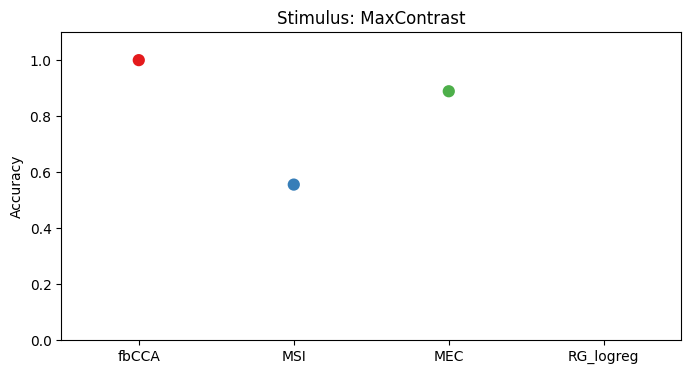

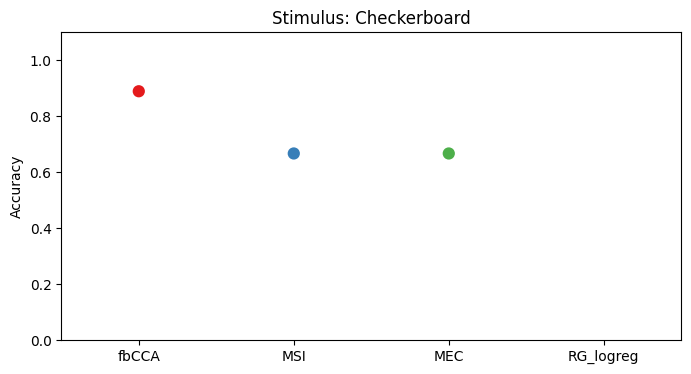

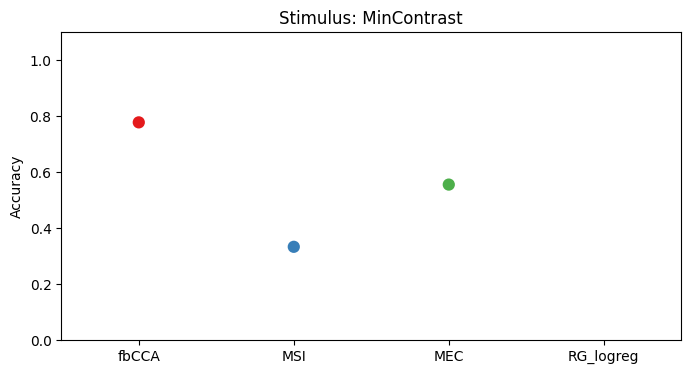

In [5]:
classifiers = ['fbCCA', 'MSI', 'MEC']

for (s,stimulus) in enumerate(stimulus_types):
    stimulus_accuracy = accuracy_df[accuracy_df["Stimulus"]==stimulus]

    fig, ax = plt.subplots(facecolor="white", figsize=[8, 4])
    sns.stripplot(
        data=stimulus_accuracy,
        ax=ax,
        jitter=True,
        alpha=0.5,
        zorder=1,
        palette="Set1",
    )
    sns.pointplot(data=stimulus_accuracy, ax=ax, palette="Set1")
    ax.set_ylabel("Accuracy")
    ax.set_ylim(0, 1.1)
    ax.set_title(f"Stimulus: {stimulus}")
    plt.show()